# End-to-End Semantic Transmission Pipeline 

This notebook breaks down the entire Joint Source-Channel Coding (JSCC) pipeline step-by-step. We will train our Semantic AI on the Europarl dataset, and then visually trace a single sentence as it is converted into math, compressed into a ht,ct from lstm, corrupted by awgn, and finally correctly decoded back into text based on training weights

In [1]:
%matplotlib inline
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(r'C:\Users\Shrish\Desktop\semantic-comm\actual_project'))
from src.data_loader import EuroparlDataLoader
from src.tokenizer import SemanticTokenizer
from src.model import JointSemanticModel

print("Loaded")

Loaded


###Loading Europarl Data & Tokenization
apne gpu ke hisaab se dekh lo , mera utna accha nhi h to main 3000 le rha sentence from europarl dataset

In [2]:
data_dir = r"C:\Users\Shrish\Desktop\semantic-comm\Semantic_Communication\europarl\en\en"
loader = EuroparlDataLoader(data_dir=data_dir, target_sentences=3000)
loader.scan_and_load()

if len(loader.all_sentences) == 0:
    print("install europarl , using dummy instead")
    sentences = ["the quick brown fox jumps over the lazy dog", "semantic communication bypasses shannon limits"] * 500
else:
    sentences = loader.all_sentences

tokenizer = SemanticTokenizer(min_freq=2)
tokenizer.fit(sentences)

print(f"Loaded {len(sentences)} sentences. Vocabulary Size: {tokenizer.vocab_size}")

#dataset creation
class SemanticDataset(Dataset):
    def __init__(self, sents, tok, max_l=15):
        self.sents = sents
        self.tok = tok
        self.max_l = max_l
    def __len__(self): return len(self.sents)
    def __getitem__(self, idx):
        return torch.tensor(self.tok.encode(self.sents[idx], max_length=self.max_l), dtype=torch.long)

max_length = 15
dataset = SemanticDataset(sentences, tokenizer, max_l=max_length)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

Scanning dataset to build vocabulary...
dictionary size: 6617
Loaded 2945 sentences. Vocabulary Size: 6617


###Live Training Loop 
We train the model for 25 epochs at a harsh 5.0 dB SNR. reciever will learn to decode text

In [3]:
model = JointSemanticModel(vocab_size=tokenizer.vocab_size, embed_dim=64, hidden_dim=128, snr_db=5.0)
optimizer = optim.Adam(model.parameters(), lr=0.002)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.PAD_ID)

epochs = 25
print(f"Training for {epochs} epochs. wait...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in dataloader:
        optimizer.zero_grad()
        outputs = model(batch, batch)
        outputs_flat = outputs[:, :-1, :].reshape(-1, tokenizer.vocab_size)
        targets_flat = batch[:, 1:].reshape(-1)
        loss = criterion(outputs_flat, targets_flat)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Average Loss: {total_loss/len(dataloader):.4f}")

print("training done")

Training for 25 epochs. wait...
Epoch 5/25 | Average Loss: 5.1147
Epoch 10/25 | Average Loss: 4.4424
Epoch 15/25 | Average Loss: 3.7659
Epoch 20/25 | Average Loss: 3.2238
Epoch 25/25 | Average Loss: 2.7691
training done


### Step 3: Preparing a Message for Transmission
We select a real, unseen sentence from the dataset and convert it into discrete math.

In [4]:
model.eval()
raw_sentence = "i have lost my mind fo her , and no one noticed"
tokens = tokenizer.encode(raw_sentence, max_length=max_length)
token_tensor = torch.tensor([tokens], dtype=torch.long)

print(f"Raw Sentence: '{raw_sentence}'")
print(f"Discrete Tokens (Math): {tokens}")

Raw Sentence: 'i have lost my mind fo her , and no one noticed'
Discrete Tokens (Math): [2, 8, 42, 3243, 159, 619, 1, 130, 19, 20, 354, 107, 3430, 3, 0]


###embedding vector
The integer tokens are converted into dense mathematical vectors by the learned embedding matrix.

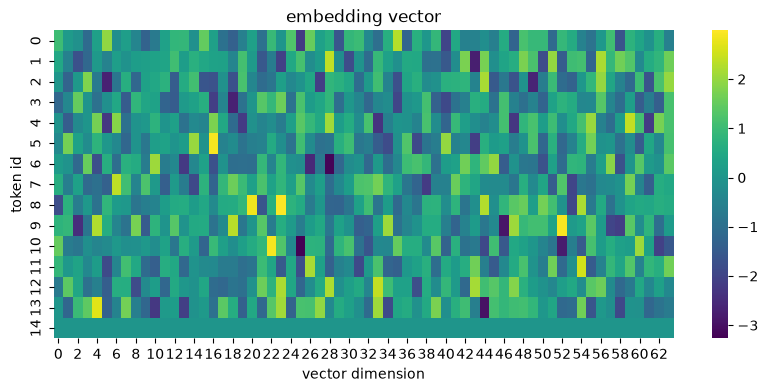

In [6]:
with torch.no_grad():
    embedded_sequence = model.encoder.embedding(token_tensor)

plt.figure(figsize=(10, 4))
sns.heatmap(embedded_sequence[0].numpy(), cmap="viridis", cbar=True)
plt.title("embedding vector")
plt.xlabel("vector dimension")
plt.ylabel("token id")
plt.show()

###The LSTM Bottleneck $z = [h_t, c_t]$
The matrix is compressed into a single, highly dense vector payload representing the deep meaning of the sentence basically semantic meaning of sentence

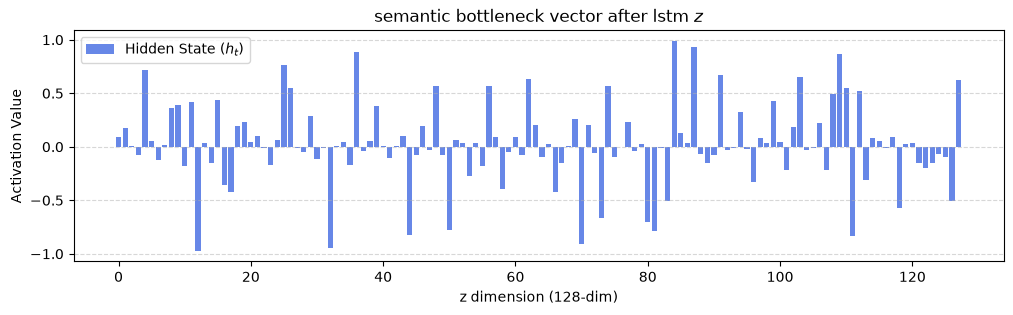

In [7]:
with torch.no_grad():
    _, (hidden_state, cell_state) = model.encoder.lstm(embedded_sequence)

plt.figure(figsize=(12, 3))
plt.bar(range(128), hidden_state[0, 0, :].numpy(), color='royalblue', alpha=0.8, label="Hidden State ($h_t$)")
plt.title("semantic bottleneck vector after lstm $z$")
plt.xlabel("z dimension (128-dim)")
plt.ylabel("Activation Value")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

###Passing through the Physical AWGN medium of 5db


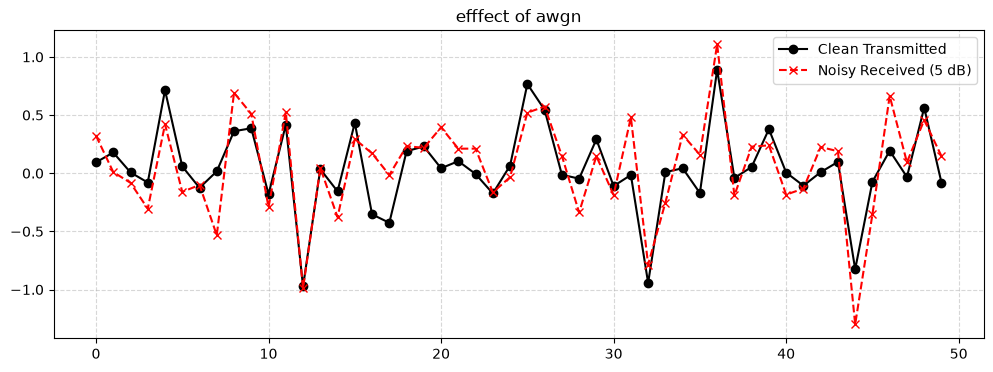

In [8]:
with torch.no_grad():
    noisy_hidden = model.channel(hidden_state, snr_db_override=5.0)
    noisy_cell = model.channel(cell_state, snr_db_override=5.0)

plt.figure(figsize=(12, 4))
plt.plot(hidden_state[0, 0, :50].numpy(), label='Clean Transmitted', marker='o', linestyle='-', color='black')
plt.plot(noisy_hidden[0, 0, :50].numpy(), label='Noisy Received (5 dB)', marker='x', linestyle='--', color='red')
plt.title("efffect of awgn")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### decoding
the reciever knows how to filter out noise and get semantic meaning of sentence back

In [12]:
with torch.no_grad():
    input_step = torch.tensor([[tokenizer.BOS_ID]], dtype=torch.long)
    h, c = noisy_hidden, noisy_cell
    predicted_tokens = []
    
    for _ in range(max_length):
        prediction, h, c = model.decoder(input_step, h, c)
        predicted_id = torch.argmax(prediction, dim=1).item()
        predicted_tokens.append(predicted_id)
        
        input_step = torch.tensor([[predicted_id]], dtype=torch.long)
        if predicted_id == tokenizer.EOS_ID:
            break

reconstructed_text = tokenizer.decode(predicted_tokens)

print(f"Transmitted: '{raw_sentence}'")
print(f"Received:    '{reconstructed_text}'")
print("not that accurate as training btch size was small")


Transmitted: 'i have lost my mind fo her , and no one noticed'
Received:    'have by <UNK> mr, behalf the s and of'
not that accurate as training btch size was small
